In [68]:
# Import Libraries
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

In [69]:
# Load Data
data = pd.read_csv('test.csv')



In [70]:
# Strip spaces in column names
data.columns = data.columns.str.strip()

# Check the column names
print(data.columns)

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3'],
      dtype='object')


In [71]:
data.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,1000004,P00128942,M,46-50,7,B,2,1,1,11.0,NaN
1,1000009,P00113442,M,26-35,17,C,0,0,3,5.0,NaN
2,1000010,P00288442,F,36-45,1,B,4+,1,5,14.0,NaN
3,1000010,P00145342,F,36-45,1,B,4+,1,4,9.0,NaN
4,1000011,P00053842,F,26-35,1,C,1,0,4,5.0,12.0


In [72]:
data.shape

(233599, 11)

In [73]:
data.info

<bound method DataFrame.info of         User_ID Product_ID Gender    Age  Occupation City_Category  \
0       1000004  P00128942      M  46-50           7             B   
1       1000009  P00113442      M  26-35          17             C   
2       1000010  P00288442      F  36-45           1             B   
3       1000010  P00145342      F  36-45           1             B   
4       1000011  P00053842      F  26-35           1             C   
...         ...        ...    ...    ...         ...           ...   
233594  1006036  P00118942      F  26-35          15             B   
233595  1006036  P00254642      F  26-35          15             B   
233596  1006036  P00031842      F  26-35          15             B   
233597  1006037  P00124742      F  46-50           1             C   
233598  1006039  P00316642      F  46-50           0             B   

       Stay_In_Current_City_Years  Marital_Status  Product_Category_1  \
0                               2               1     

In [74]:
data.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2             72344
Product_Category_3            162562
dtype: int64

In [75]:
data.isnull().sum()/data.shape[0]*100

User_ID                        0.000000
Product_ID                     0.000000
Gender                         0.000000
Age                            0.000000
Occupation                     0.000000
City_Category                  0.000000
Stay_In_Current_City_Years     0.000000
Marital_Status                 0.000000
Product_Category_1             0.000000
Product_Category_2            30.969311
Product_Category_3            69.590195
dtype: float64

In [76]:
data.nunique()

User_ID                       5891
Product_ID                    3491
Gender                           2
Age                              7
Occupation                      21
City_Category                    3
Stay_In_Current_City_Years       5
Marital_Status                   2
Product_Category_1              18
Product_Category_2              17
Product_Category_3              15
dtype: int64

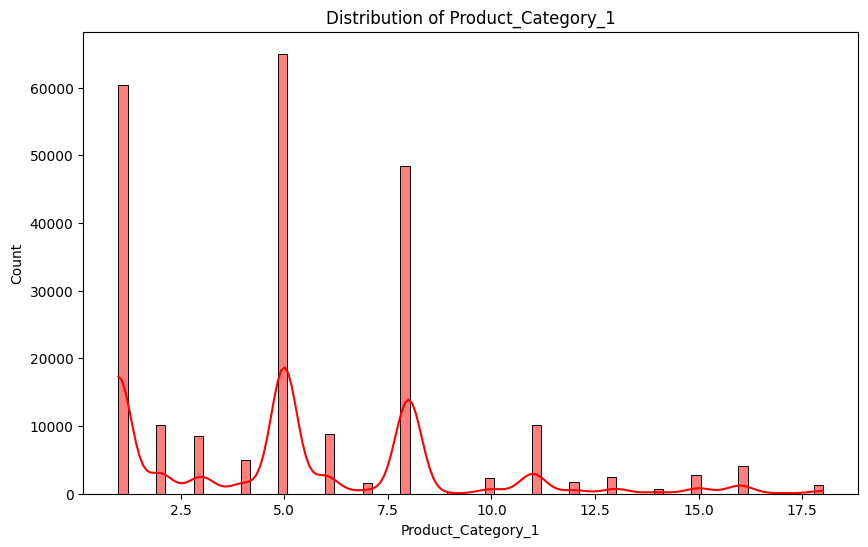

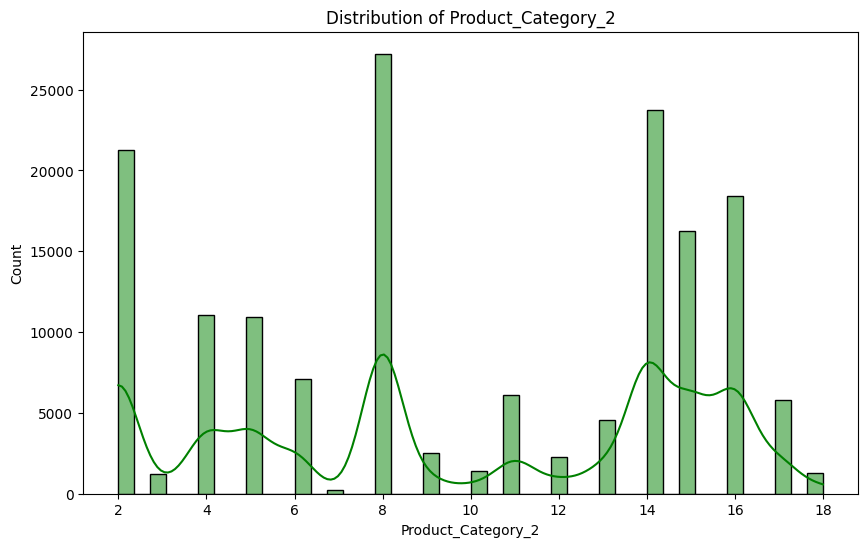

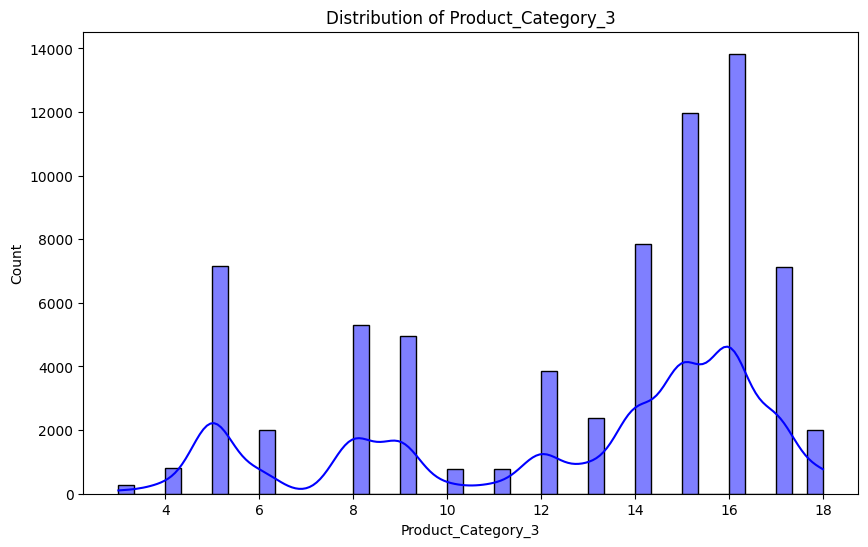

In [77]:
# Plot for Product_Category_1
plt.figure(figsize=(10, 6))
sns.histplot(data['Product_Category_1'], color='r', kde=True)
plt.title("Distribution of Product_Category_1")
plt.show()

# Plot for Product_Category_2
plt.figure(figsize=(10, 6))
sns.histplot(data['Product_Category_2'], color='g', kde=True)
plt.title("Distribution of Product_Category_2")
plt.show()

# Plot for Product_Category_3
plt.figure(figsize=(10, 6))
sns.histplot(data['Product_Category_3'], color='b', kde=True)
plt.title("Distribution of Product_Category_3")
plt.show()


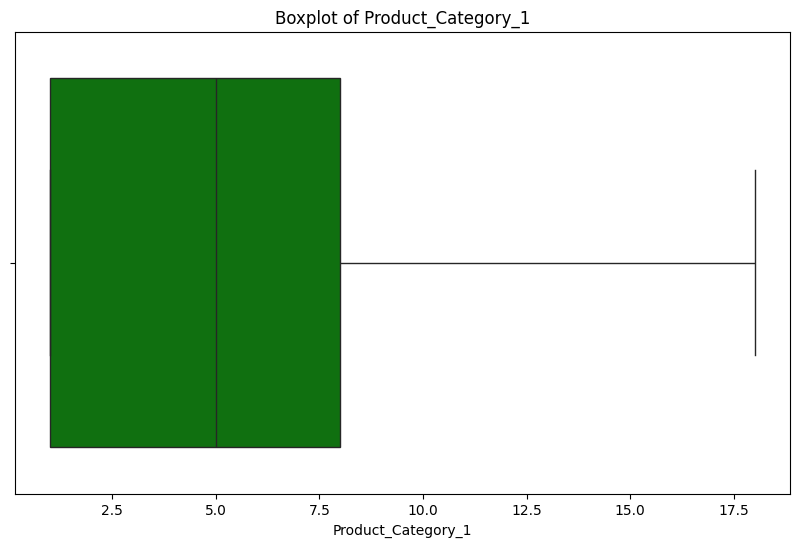

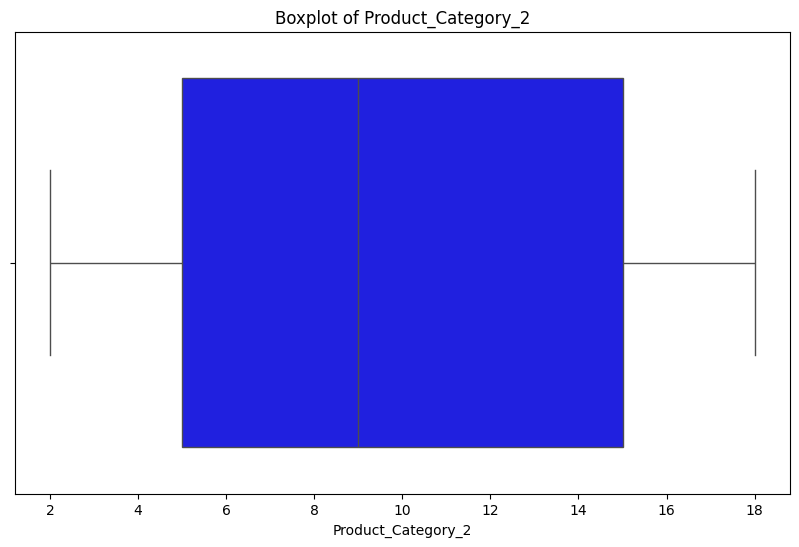

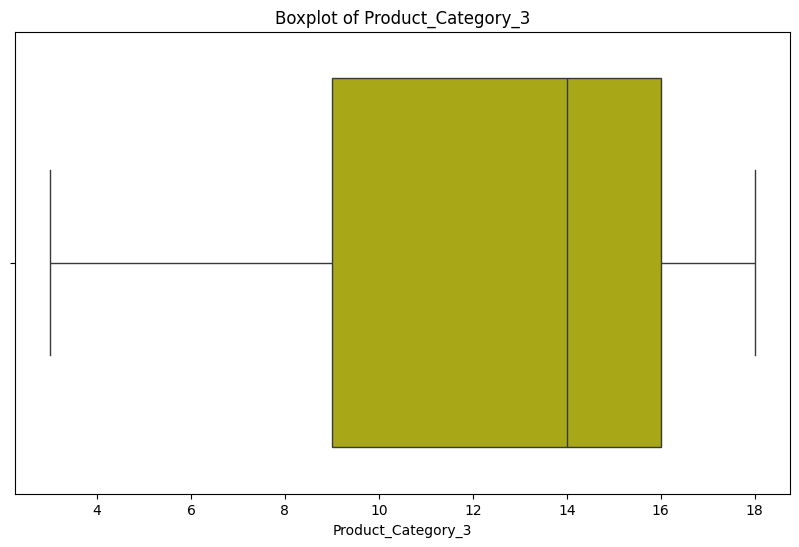

In [78]:

# Boxplot for Product_Category_1
plt.figure(figsize=(10, 6))
sns.boxplot(x=data["Product_Category_1"], color='g')
plt.title("Boxplot of Product_Category_1")
plt.show()

# Boxplot for Product_Category_2
plt.figure(figsize=(10, 6))
sns.boxplot(x=data["Product_Category_2"], color='b')
plt.title("Boxplot of Product_Category_2")
plt.show()

# Boxplot for Product_Category_3
plt.figure(figsize=(10, 6))
sns.boxplot(x=data["Product_Category_3"], color='y')
plt.title("Boxplot of Product_Category_3")
plt.show()

In [79]:
# Calculate and display skewness for Product_Category_1, Product_Category_2, and Product_Category_3
categories = ['Product_Category_1', 'Product_Category_2', 'Product_Category_3']

for category in categories:
    skewness = data[category].skew()
    print(f"Skewness of {category}: {skewness:.2f}")

Skewness of Product_Category_1: 0.87
Skewness of Product_Category_2: -0.17
Skewness of Product_Category_3: -0.77


In [80]:
# Calculate and display kurtosis for Product_Category_1, Product_Category_2, and Product_Category_3
product_category_kurtosis = {
    'Product_Category_1': data["Product_Category_1"].kurtosis(),
    'Product_Category_2': data["Product_Category_2"].kurtosis(),
    'Product_Category_3': data["Product_Category_3"].kurtosis()
}

for category, kurtosis_value in product_category_kurtosis.items():
    print(f"Kurtosis of {category}: {kurtosis_value:.2f}")

Kurtosis of Product_Category_1: 0.71
Kurtosis of Product_Category_2: -1.43
Kurtosis of Product_Category_3: -0.80


In [81]:
# Get descriptive statistics for Product_Category_1, Product_Category_2, and Product_Category_3
product_category_desc = data[["Product_Category_1", "Product_Category_2", "Product_Category_3"]].describe()

# Display the descriptive statistics
print(product_category_desc)


       Product_Category_1  Product_Category_2  Product_Category_3
count       233599.000000       161255.000000        71037.000000
mean             5.276542            9.849586           12.669454
std              3.736380            5.094943            4.125944
min              1.000000            2.000000            3.000000
25%              1.000000            5.000000            9.000000
50%              5.000000            9.000000           14.000000
75%              8.000000           15.000000           16.000000
max             18.000000           18.000000           18.000000


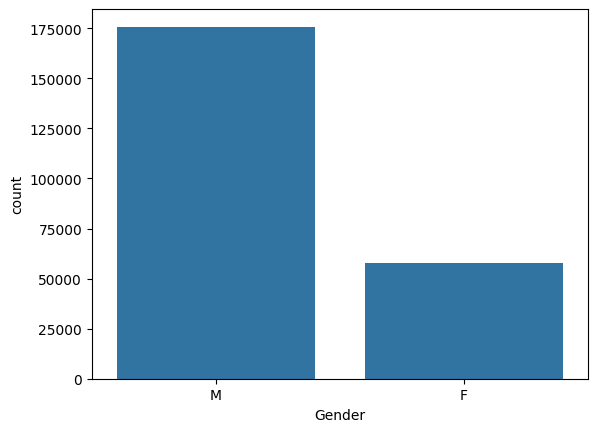

In [82]:
sns.countplot(x='Gender', data=data)
plt.show()

In [83]:
data['Gender'].value_counts(normalize=True)*100

Gender
M    75.245185
F    24.754815
Name: proportion, dtype: float64

In [84]:
# Group by 'Gender' and calculate the mean of 'Purchase' for each product category
grouped_purchase = data.groupby("Gender")[['Product_Category_1', 'Product_Category_2', 'Product_Category_3']].mean()

# Display the result
print(grouped_purchase)


        Product_Category_1  Product_Category_2  Product_Category_3
Gender                                                            
F                 5.588116            9.995012           12.486741
M                 5.174038            9.802737           12.722687


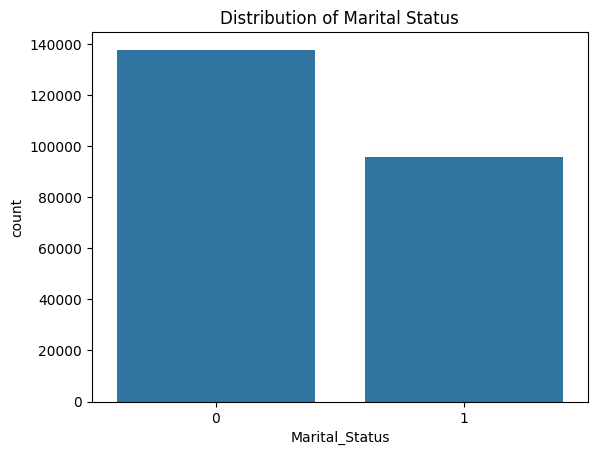

In [85]:
# Load the dataset 
data = pd.read_csv('test.csv')

# Create the countplot for 'Marital_Status'
sns.countplot(x='Marital_Status', data=data)

# Add a title to the plot
plt.title("Distribution of Marital Status")

# Display the plot
plt.show()

In [86]:
# Group by Marital_Status and calculate the mean of Purchase for each product category
marital_status_purchase = data.groupby("Marital_Status")[['Product_Category_1', 'Product_Category_2', 'Product_Category_3']].mean()

# Display the result
print(marital_status_purchase)


                Product_Category_1  Product_Category_2  Product_Category_3
Marital_Status                                                            
0                         5.217790            9.757448           12.614925
1                         5.361064            9.983054           12.750569


In [87]:
# Group by 'Occupation' and 'Product_Category_1', 'Product_Category_2', 'Product_Category_3'
occup = data.groupby("Occupation")[["Product_Category_1", "Product_Category_2", "Product_Category_3"]].mean()
# Display the result
print(occup)

            Product_Category_1  Product_Category_2  Product_Category_3
Occupation                                                            
0                     5.328358            9.859770           12.673988
1                     5.568975           10.130972           12.827363
2                     5.482819            9.946499           12.608534
3                     5.530765           10.068385           12.688065
4                     5.082429            9.582319           12.495678
5                     5.080639            9.602099           12.502814
6                     5.453298            9.983068           12.783607
7                     5.269105            9.964725           12.776741
8                     4.525661            9.023256           12.428571
9                     5.360500            9.755826           12.159420
10                    4.780796            8.921100           11.741398
11                    5.364290            9.854412           12.667569
12    

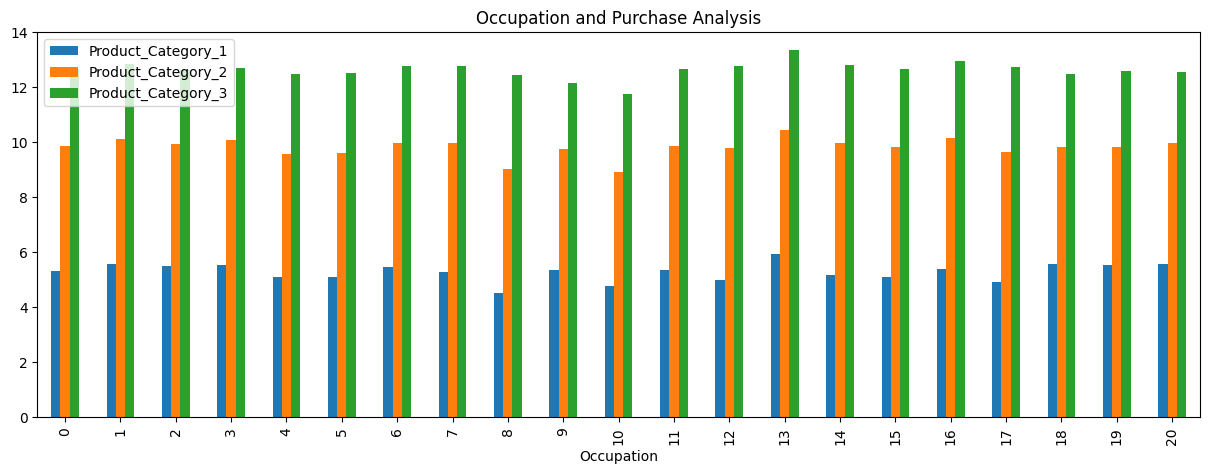

In [88]:
occup.plot(kind='bar',figsize=(15,5))
plt.title("Occupation and Purchase Analysis")
plt.show()

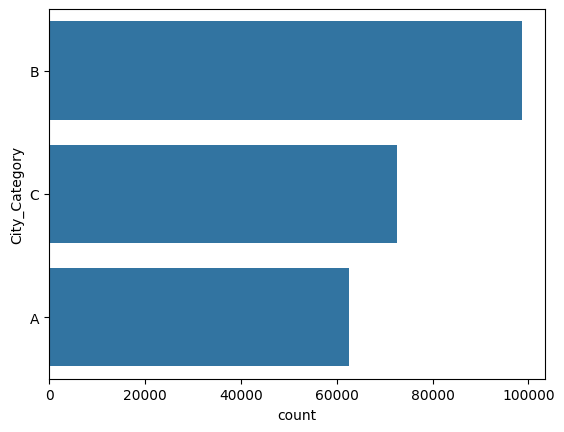

In [89]:
sns.countplot(data['City_Category'])
plt.show()

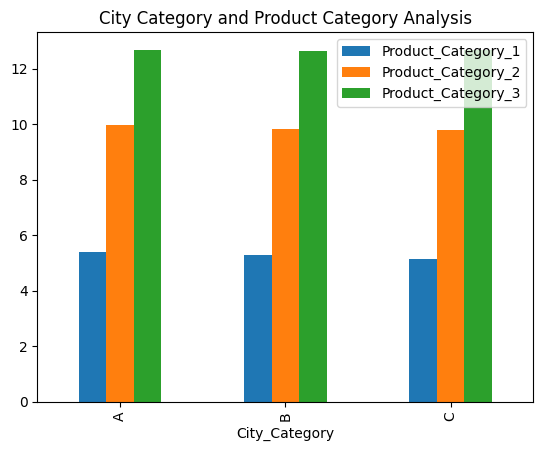

In [90]:

# Group by 'City_Category' and calculate mean for 'Product_Category_1', 'Product_Category_2', 'Product_Category_3'
data.groupby("City_Category")[["Product_Category_1", "Product_Category_2", "Product_Category_3"]].mean().plot(kind='bar')

# Set the title and display the plot
plt.title("City Category and Product Category Analysis")
plt.show()


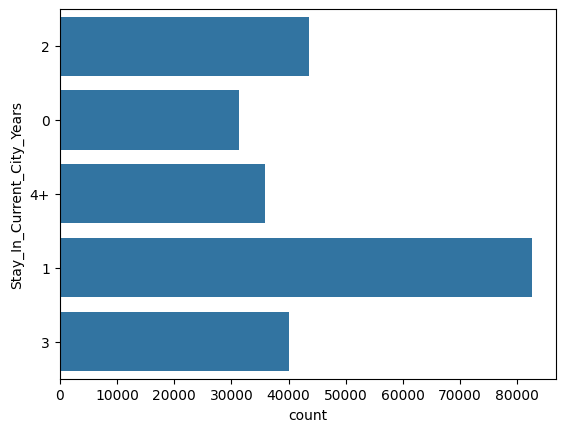

In [91]:
sns.countplot(data['Stay_In_Current_City_Years'])
plt.show()

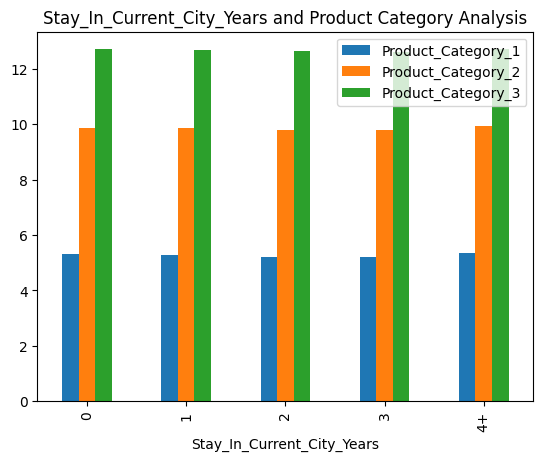

In [92]:

# Group by 'Stay_In_Current_City_Years' and calculate mean for 'Product_Category_1', 'Product_Category_2', 'Product_Category_3'
data.groupby("Stay_In_Current_City_Years")[["Product_Category_1", "Product_Category_2", "Product_Category_3"]].mean().plot(kind='bar')

# Set the title and display the plot
plt.title("Stay_In_Current_City_Years and Product Category Analysis")
plt.show()


In [93]:
def preprocess_age(age):
    age_mapping = {
        '0-17': 1,
        '18-25': 2,
        '26-35': 3,
        '36-45': 4,
        '46-50': 5,
        '51-55': 6,
        '55+': 7
    }
    return age_mapping.get(age, 0)

data['Age'] = data['Age'].apply(preprocess_age)

# Handle missing values without the FutureWarning
for col in ['Product_Category_2', 'Product_Category_3']:
    data[col] = data[col].fillna(0)

# Since the columns Gender, City_Category, and Stay_In_Current_City_Years are already encoded
# No need to apply get_dummies for them

# Validate Columns after encoding
print("Columns after encoding:", data.columns)

Columns after encoding: Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3'],
      dtype='object')


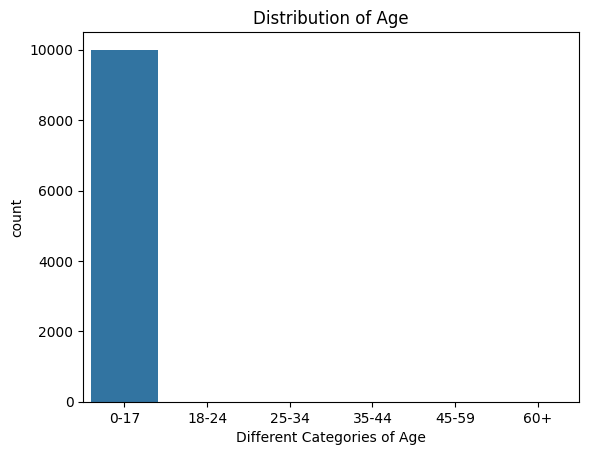

In [94]:
if len(data) > 10000:
    data_sample = data.sample(10000)
else:
    data_sample = data

# Grouping 'Age' into broader categories
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ['0-17', '18-24', '25-34', '35-44', '45-59', '60+']
data_sample['Age Group'] = pd.cut(data_sample['Age'], bins=bins, labels=labels)

sns.countplot(data=data_sample, x='Age Group')
plt.title('Distribution of Age')
plt.xlabel('Different Categories of Age')
plt.show()

In [95]:
# List of specific feature columns (excluding 'Purchase')
features = ['Age', 'Occupation', 'Marital_Status', 
            'Product_Category_1', 'Product_Category_2', 
            'Product_Category_3'] + \
           [col for col in data.columns if col.startswith(('Gender_', 'City_Category_', 'Stay_In_Current_City_Years_'))]
target = 'Purchase'


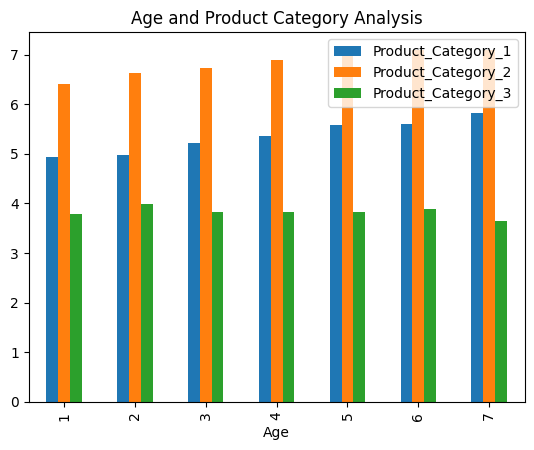

In [96]:
data.groupby("Age")[["Product_Category_1", "Product_Category_2", "Product_Category_3"]].mean().plot(kind='bar')
plt.title("Age and Product Category Analysis")
plt.show()


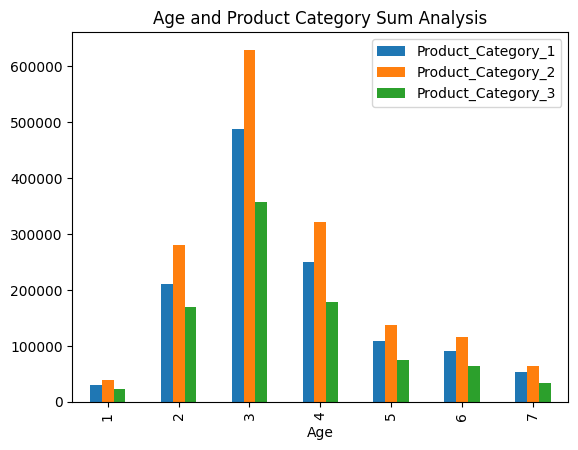

In [97]:

data.groupby("Age")[["Product_Category_1", "Product_Category_2", "Product_Category_3"]].sum().plot(kind='bar')
plt.title("Age and Product Category Sum Analysis")
plt.show()


In [98]:
# Define the features
features = ['Age', 'Occupation', 'Marital_Status', 'Product_Category_1', 
            'Product_Category_2', 'Product_Category_3'] + \
            [col for col in data.columns if col.startswith(('Gender_', 'City_Category_', 'Stay_In_Current_City_Years_'))]
X = data[features]

In [ ]:
# Slice the dataset to include only the first 1000 rows
data_subset = data.head(1000)

# Define custom colors for each category
custom_colors = ['#FF6347', '#8A2BE2', '#3CB371', '#FF4500', '#FFD700']

# Set the figure size
plt.figure(figsize=(18, 5))

# Create a countplot with custom colors for each bar
sns.countplot(data=data_subset, x='Product_Category_1', palette=custom_colors)

# Display the plot
plt.title("Countplot of Product_Category_1 ")
plt.show()


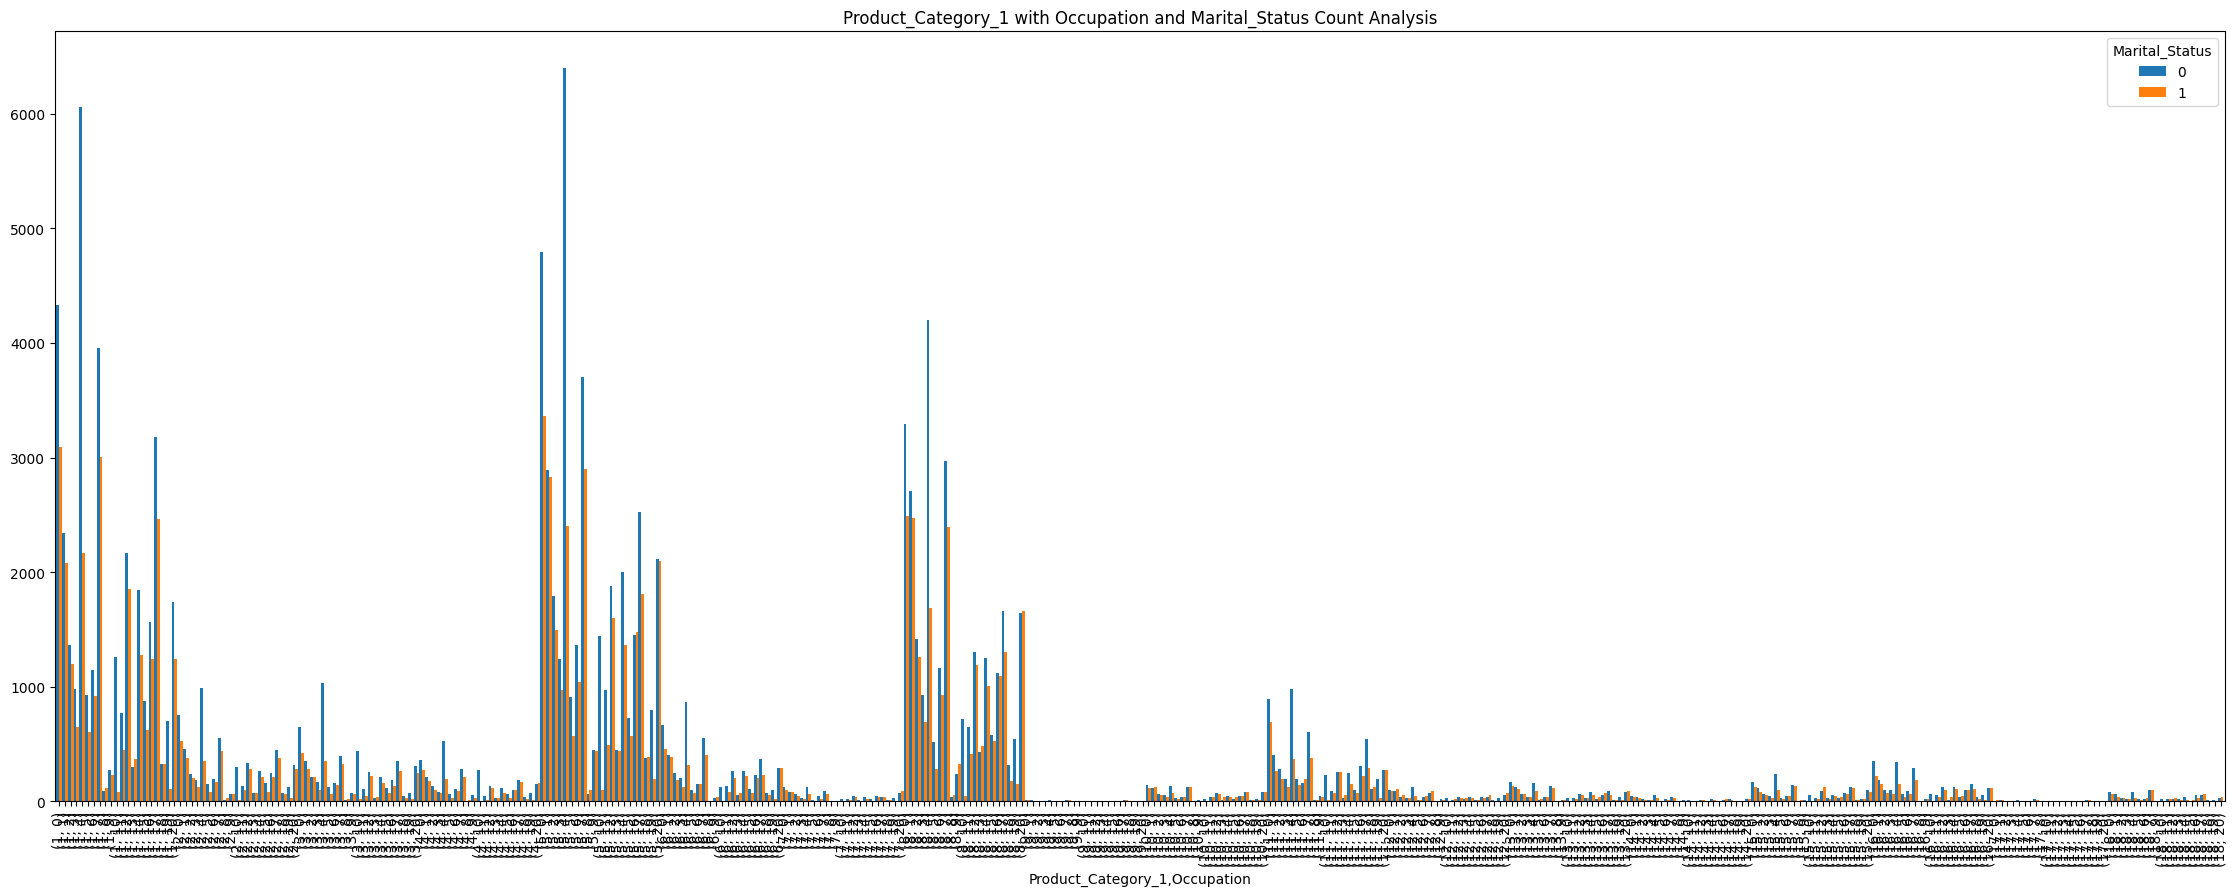

In [100]:
# Group by 'Product_Category_1' and include 'Occupation' and 'Marital_Status' (considering them as categorical)
data_grouped = data.groupby(['Product_Category_1', 'Occupation', 'Marital_Status']).size().unstack(fill_value=0)

# Plot the grouped data with larger bars
data_grouped.plot(kind='bar', figsize=(28, 10), width=1.0)  # Set width to 1.0 for wider bars

# Set the title and display the plot
plt.title("Product_Category_1 with Occupation and Marital_Status Count Analysis")
plt.show()

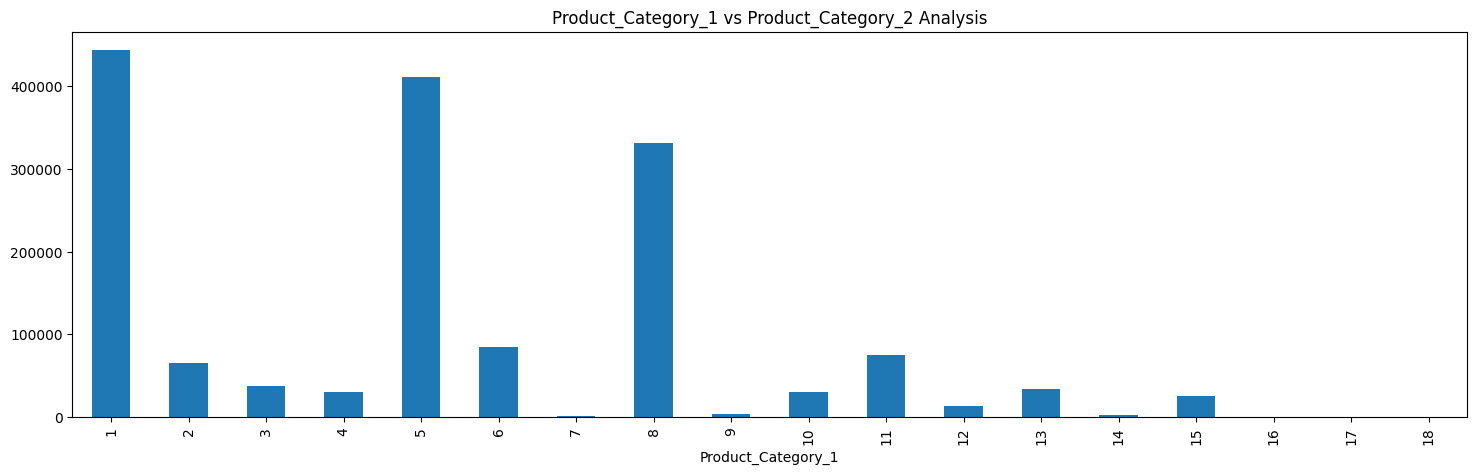

In [101]:
# Group by 'Product_Category_1' and sum the relevant column (e.g., 'Product_Category_2' or 'Product_Category_3')
data_grouped = data.groupby('Product_Category_1').sum()
data_grouped['Product_Category_2'].plot(kind='bar', figsize=(18, 5))

# Set the title and display the plot
plt.title("Product_Category_1 vs Product_Category_2 Analysis")
plt.show()


In [ ]:
# Slice the dataset to include only the first 1000 rows
data_subset = data.head(1000)

# Define custom colors for each category
custom_colors = ['#FF6347', '#8A2BE2', '#3CB371', '#FF4500', '#FFD700']

# Set the figure size
plt.figure(figsize=(18, 5))

# Create a countplot with custom colors for each bar
sns.countplot(data=data_subset, x='Product_Category_2', palette=custom_colors)

# Display the plot
plt.title("Countplot of Product_Category_2 ")
plt.show()


In [ ]:
# Slice the dataset to include only the first 1000 rows
data_subset = data.head(1000)

# Define custom colors for each category
custom_colors = ['#FF6347', '#8A2BE2', '#3CB371', '#FF4500', '#FFD700']

# Set the figure size
plt.figure(figsize=(18, 5))

# Create a countplot with custom colors for each bar
sns.countplot(data=data_subset, x='Product_Category_3', palette=custom_colors)

# Display the plot
plt.title("Countplot of Product_Category_3 ")
plt.show()


In [109]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Prepare data
features = ['Age', 'Occupation', 'Marital_Status', 'Product_Category_1', 
            'Product_Category_2', 'Product_Category_3']
X = data[features]
y = data['Product_Category_1']  # Replace 'Target_Variable' with the column name you want to use

# Handle missing values and encode categorical data
X = SimpleImputer(strategy='median').fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [110]:
# Select only numeric columns from the dataset
numeric_data = data.select_dtypes(include=['number'])

# Compute correlation matrix for numeric columns
corr_matrix = numeric_data.corr()

# Display the correlation matrix
print(corr_matrix)

                     User_ID       Age  Occupation  Marital_Status  \
User_ID             1.000000  0.031642   -0.023988        0.019883   
Age                 0.031642  1.000000    0.089509        0.308407   
Occupation         -0.023988  0.089509    1.000000        0.021872   
Marital_Status      0.019883  0.308407    0.021872        1.000000   
Product_Category_1  0.006428  0.058295   -0.010465        0.018860   
Product_Category_2  0.003590  0.025161    0.009089        0.008597   
Product_Category_3 -0.000533 -0.006527    0.013456       -0.006879   

                    Product_Category_1  Product_Category_2  Product_Category_3  
User_ID                       0.006428            0.003590           -0.000533  
Age                           0.058295            0.025161           -0.006527  
Occupation                   -0.010465            0.009089            0.013456  
Marital_Status                0.018860            0.008597           -0.006879  
Product_Category_1            1.00

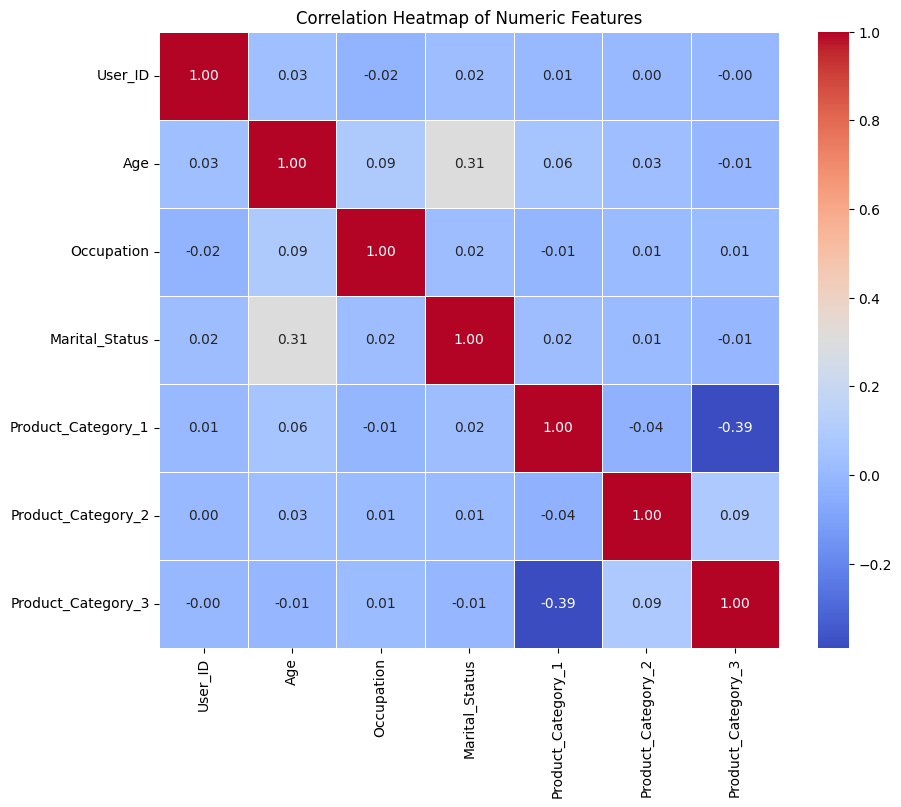

In [111]:
# Select only numeric columns from the dataset
numeric_data = data.select_dtypes(include=['number'])

# Create a heatmap for the correlation matrix of numeric columns
plt.figure(figsize=(10, 8))  # Adjust the figure size as needed
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Display the plot
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [112]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")

RMSE: 0.00


In [113]:
data.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3'],
      dtype='object')

In [114]:
df = data.copy()

In [115]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,1000004,P00128942,M,5,7,B,2,1,1,11.0,0.0
1,1000009,P00113442,M,3,17,C,0,0,3,5.0,0.0
2,1000010,P00288442,F,4,1,B,4+,1,5,14.0,0.0
3,1000010,P00145342,F,4,1,B,4+,1,4,9.0,0.0
4,1000011,P00053842,F,3,1,C,1,0,4,5.0,12.0


In [116]:
df = pd.get_dummies(df, columns=['Stay_In_Current_City_Years'])

In [118]:
from sklearn.preprocessing import LabelEncoder
lr = LabelEncoder()
df['Gender'] = lr.fit_transform(df['Gender'])
df['Age'] = lr.fit_transform(df['Age'])
df['City_Category'] = lr.fit_transform(df['City_Category'])

In [117]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Stay_In_Current_City_Years_0,Stay_In_Current_City_Years_1,Stay_In_Current_City_Years_2,Stay_In_Current_City_Years_3,Stay_In_Current_City_Years_4+
0,1000004,P00128942,M,5,7,B,1,1,11.0,0.0,False,False,True,False,False
1,1000009,P00113442,M,3,17,C,0,3,5.0,0.0,True,False,False,False,False
2,1000010,P00288442,F,4,1,B,1,5,14.0,0.0,False,False,False,False,True
3,1000010,P00145342,F,4,1,B,1,4,9.0,0.0,False,False,False,False,True
4,1000011,P00053842,F,3,1,C,0,4,5.0,12.0,False,True,False,False,False


In [119]:
df['Product_Category_2'] =df['Product_Category_2'].fillna(0).astype('int64')
df['Product_Category_3'] =df['Product_Category_3'].fillna(0).astype('int64')

In [120]:
df.isnull().sum()

User_ID                          0
Product_ID                       0
Gender                           0
Age                              0
Occupation                       0
City_Category                    0
Marital_Status                   0
Product_Category_1               0
Product_Category_2               0
Product_Category_3               0
Stay_In_Current_City_Years_0     0
Stay_In_Current_City_Years_1     0
Stay_In_Current_City_Years_2     0
Stay_In_Current_City_Years_3     0
Stay_In_Current_City_Years_4+    0
dtype: int64

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233599 entries, 0 to 233598
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   User_ID                        233599 non-null  int64 
 1   Product_ID                     233599 non-null  object
 2   Gender                         233599 non-null  int32 
 3   Age                            233599 non-null  int64 
 4   Occupation                     233599 non-null  int64 
 5   City_Category                  233599 non-null  int32 
 6   Marital_Status                 233599 non-null  int64 
 7   Product_Category_1             233599 non-null  int64 
 8   Product_Category_2             233599 non-null  int64 
 9   Product_Category_3             233599 non-null  int64 
 10  Stay_In_Current_City_Years_0   233599 non-null  bool  
 11  Stay_In_Current_City_Years_1   233599 non-null  bool  
 12  Stay_In_Current_City_Years_2   233599 non-nu

In [122]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [123]:
lr.intercept_

-1.687538997430238e-13

In [124]:
lr.coef_

array([-5.87774687e-15,  3.88578059e-16,  1.71390679e-15,  1.00000000e+00,
        3.81639165e-16, -6.24500451e-17])

In [125]:
y_pred = lr.predict(X_test)
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [126]:
mean_absolute_error(y_test, y_pred)

9.919821813290721e-14

In [127]:
mean_squared_error(y_test, y_pred)

1.674107344352488e-26

In [128]:
r2_score(y_test, y_pred)

1.0

In [129]:
from math import sqrt
print("RMSE of Linear Regression Model is ",sqrt(mean_squared_error(y_test, y_pred)))

RMSE of Linear Regression Model is  1.2938730016321108e-13
